In [1]:
from lib.readwav import readwav
from lib.functions import get_f0_from_peaks, extract_harmonics, get_average_spectrum, get_adaptive_params, find_closest_note, get_f0_from_regression
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
#%matplotlib widget
#plt.close('all')

(332193, 2)
Frequenza fondamentale stimata: 1563.44 Hz


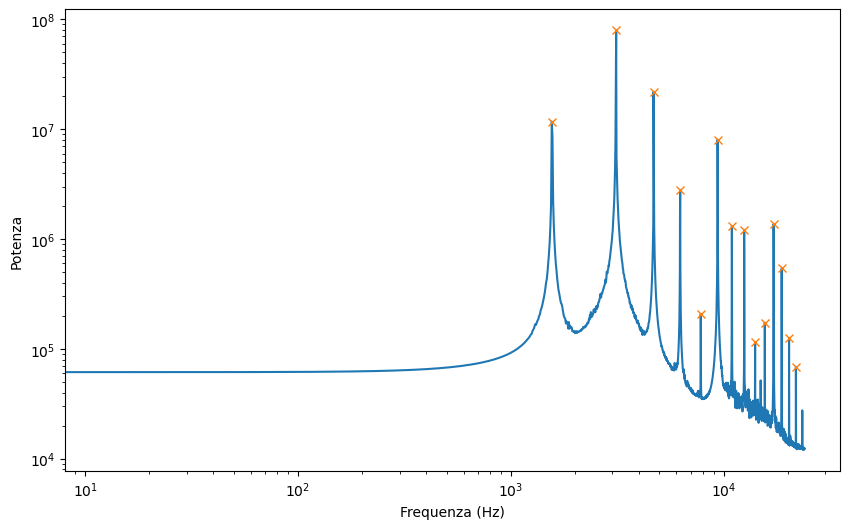

In [3]:
note_data = readwav('Data_organ/note_1.wav')
rate, data = note_data
print(data.shape)
channel1 = data[:,0]
channel2 = data[:,1]

window_size, hop_size = get_adaptive_params(channel1, rate)
freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

peaks, _ = sp.signal.find_peaks(power_spectrum, prominence=5*1e4)

f0 = get_f0_from_regression(freqs[peaks])
print(f"Frequenza fondamentale stimata: {f0:.2f} Hz")


plt.figure(figsize=(10, 6))
plt.plot(freqs, power_spectrum)
plt.plot(freqs[peaks], power_spectrum[peaks], 'x')
plt.xscale('log')
plt.xlabel('Frequenza (Hz)')
plt.ylabel('Potenza')
plt.yscale('log')
plt.show()

File indices: [1, 21, 41, 61, 81, 101, 121, 141, 161, 181, 201, 221, 241, 261]
File: note_1.wav, X primo bin depresso (alpha usato=3): 5.73e+04
File: note_21.wav, X primo bin depresso (alpha usato=3): 1.04e+06
File: note_41.wav, X primo bin depresso (alpha usato=3): 2.37e+06
File: note_61.wav, X primo bin depresso (alpha usato=3): 2.60e+05
File: note_81.wav, X primo bin depresso (alpha usato=3): 3.99e+05
File: note_101.wav, X primo bin depresso (alpha usato=3): 6.05e+05
File: note_121.wav, X primo bin depresso (alpha usato=3): 5.98e+05
File: note_141.wav, X primo bin depresso (alpha usato=3): 5.38e+05
File: note_161.wav, X primo bin depresso (alpha usato=3): 1.03e+06
File: note_181.wav, X primo bin depresso (alpha usato=3): 6.05e+05
File: note_201.wav, X primo bin depresso (alpha usato=3): 3.07e+05
File: note_221.wav, X primo bin depresso (alpha usato=3): 1.56e+05
File: note_241.wav, X primo bin depresso (alpha usato=3): 5.92e+05
File: note_261.wav, X primo bin depresso (alpha usato=3)

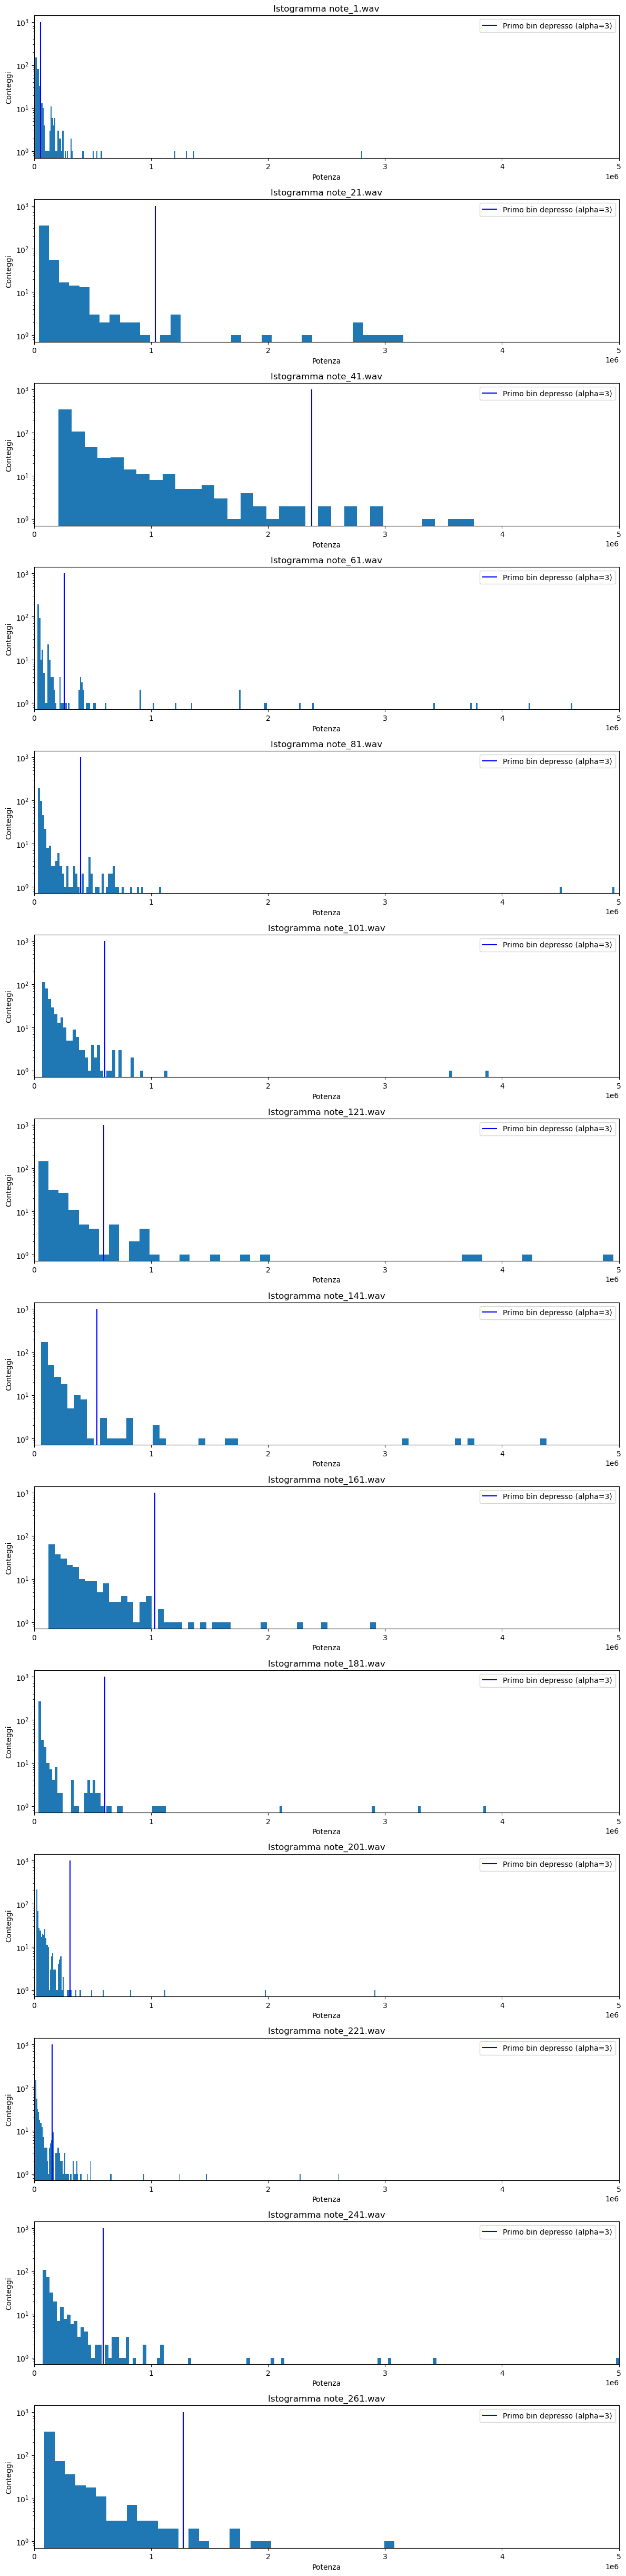

In [7]:
file_indices = list(range(1, 280, 20))
print(f"File indices: {file_indices}")

num_plots = len(file_indices)
alpha_start = 3

# salvataggio x primo bin depresso
x_depre = []

fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3.5 * num_plots))

if num_plots == 1:
    axes = [axes]

for row_index, i in enumerate(file_indices):
    note_data = readwav(f'Data_organ/note_{i}.wav')
    rate, data = note_data
    channel1 = data[:, 0]

    window_size, hop_size = get_adaptive_params(channel1, rate)
    freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

    peaks_hist, _ = sp.signal.find_peaks(power_spectrum, prominence=1e2)

    ax_hist = axes[row_index]

    hist_y, bin_edges = np.histogram(power_spectrum[peaks_hist], bins=8000)

    alpha_current = alpha_start
    dip_indices = np.array([], dtype=int)

    while alpha_current >= 1:
        dip_condition = (hist_y[1:-1] * alpha_current < hist_y[:-2]) & (hist_y[1:-1] * alpha_current < hist_y[2:])
        dip_indices = np.where(dip_condition)[0] + 1
        if dip_indices.size > 0:
            break
        alpha_current -= 1

    if dip_indices.size > 0:
        first_dip_bin_index = dip_indices[0]
        x_first_dip_bin = 0.5 * (bin_edges[first_dip_bin_index] + bin_edges[first_dip_bin_index + 1])
        alpha_used = alpha_current
    else:
        first_dip_bin_index = None
        x_first_dip_bin = np.nan
        alpha_used = np.nan

    ax_hist.hist(power_spectrum[peaks_hist], bins=8000)

    if np.isfinite(x_first_dip_bin):
        ax_hist.vlines(x_first_dip_bin, 0, 1000, colors='b', label=f'Primo bin depresso (alpha={alpha_used})')
    ax_hist.legend()
    ax_hist.set_xlim(0, 5 * 1e6)
    ax_hist.set_yscale('log')
    ax_hist.set_title(f'Istogramma note_{i}.wav')
    ax_hist.set_xlabel('Potenza')
    ax_hist.set_ylabel('Conteggi')

    print(f"File: note_{i}.wav, X primo bin depresso (alpha usato={alpha_used}): {x_first_dip_bin:.2e}")
    x_depre.append(x_first_dip_bin)

plt.tight_layout()
plt.show()

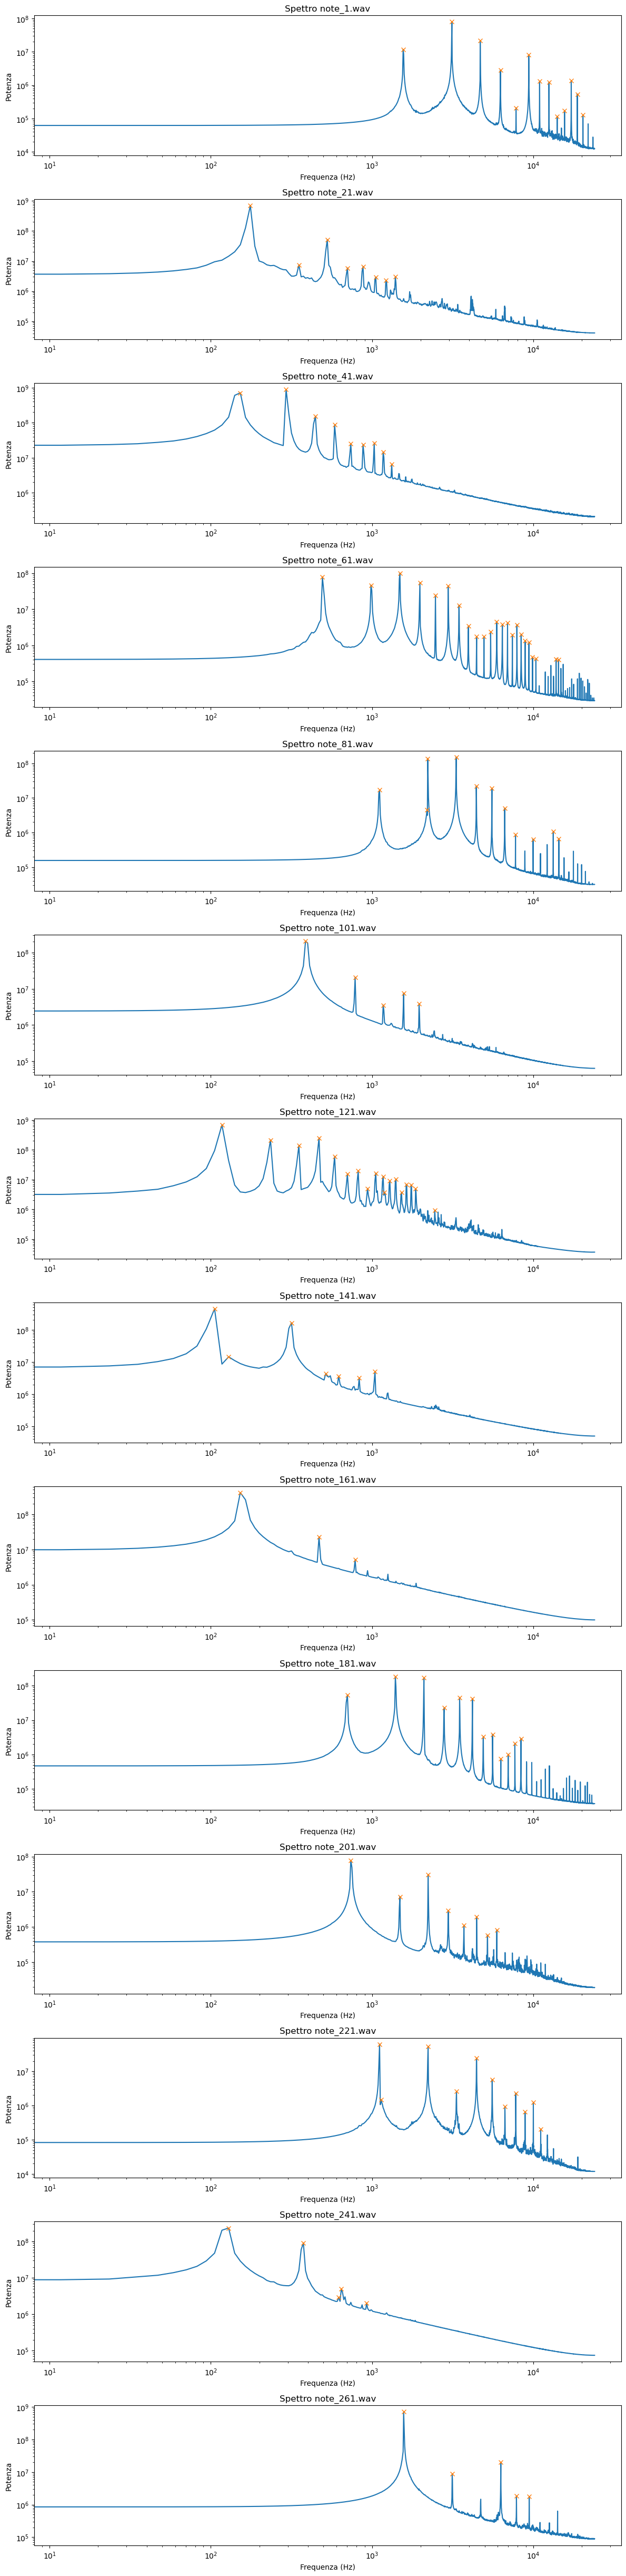

In [8]:
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3.5 * num_plots))

if num_plots == 1:
    axes = [axes]

for row_index, i in enumerate(file_indices):
    note_data = readwav(f'Data_organ/note_{i}.wav')
    rate, data = note_data
    channel1 = data[:, 0]

    window_size, hop_size = get_adaptive_params(channel1, rate)
    freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

    prominence_i = x_depre[row_index] 
    peaks, _ = sp.signal.find_peaks(power_spectrum, prominence=prominence_i)

    ax = axes[row_index]

    ax.plot(freqs, power_spectrum)
    ax.plot(freqs[peaks], power_spectrum[peaks], 'x')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f'Spettro note_{i}.wav')
    ax.set_xlabel('Frequenza (Hz)')
    ax.set_ylabel('Potenza')

plt.tight_layout()
plt.show()

File: note_1.wav, F0 stimata: 1563.57 Hz
File: note_21.wav, F0 stimata: 174.11 Hz
File: note_41.wav, F0 stimata: 146.48 Hz
File: note_61.wav, F0 stimata: 494.82 Hz
File: note_81.wav, F0 stimata: 1229.90 Hz
File: note_101.wav, F0 stimata: 392.58 Hz
File: note_121.wav, F0 stimata: 117.19 Hz
File: note_141.wav, F0 stimata: 161.55 Hz
File: note_161.wav, F0 stimata: 316.41 Hz
File: note_181.wav, F0 stimata: 699.29 Hz
File: note_201.wav, F0 stimata: 742.47 Hz
File: note_221.wav, F0 stimata: 1049.79 Hz
File: note_241.wav, F0 stimata: 186.33 Hz
File: note_261.wav, F0 stimata: 2044.92 Hz


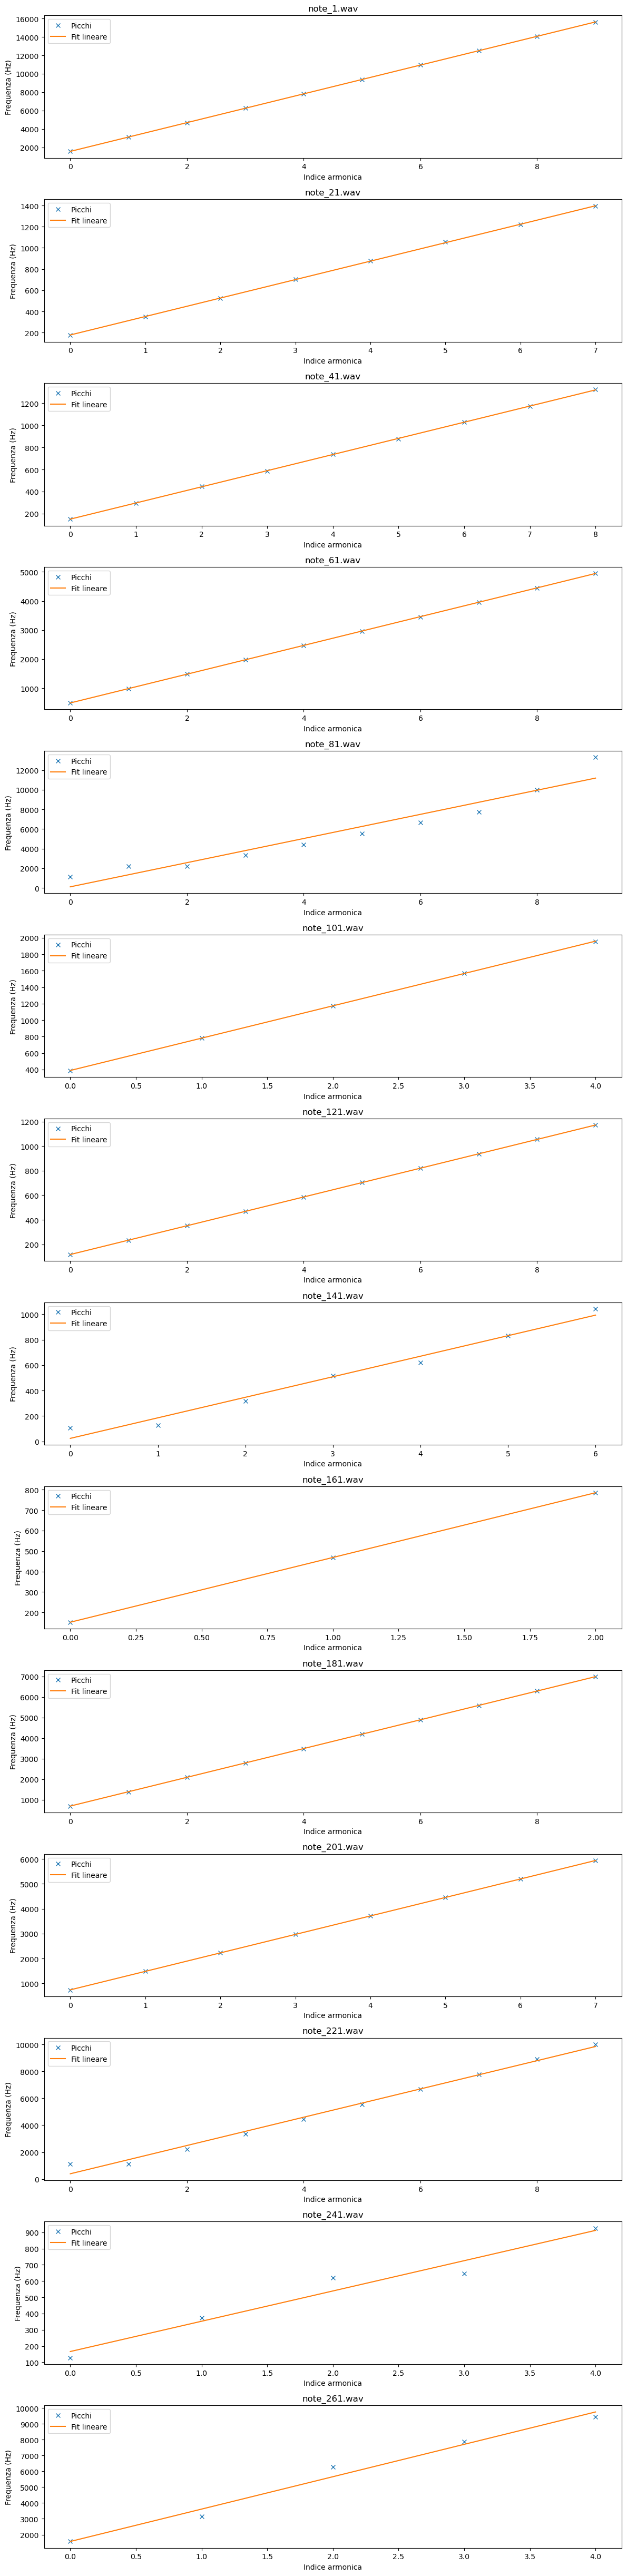

In [9]:
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 3.5 * num_plots))

if num_plots == 1:
    axes = [axes]

for row_index, i in enumerate(file_indices):
    note_data = readwav(f'Data_organ/note_{i}.wav')
    rate, data = note_data
    channel1 = data[:, 0]

    window_size, hop_size = get_adaptive_params(channel1, rate)
    freqs, power_spectrum = get_average_spectrum(channel1, rate, window_size, hop_size)

    prominence_i = x_depre[row_index] 
    peaks, _ = sp.signal.find_peaks(power_spectrum, prominence=prominence_i)
    first_10_peaks = peaks[:10]

    ax = axes[row_index]

    x = np.arange(len(first_10_peaks))
    y = freqs[first_10_peaks]

    coefficients = np.polyfit(x, y, 1)
    f0 = coefficients[0]
    print(f"File: note_{i}.wav, F0 stimata: {f0:.2f} Hz")

    ax.plot(x, y, 'x', label='Picchi')
    ax.plot(x, np.polyval(coefficients, x), label='Fit lineare')
    ax.set_title(f'note_{i}.wav')
    ax.set_xlabel('Indice armonica')
    ax.set_ylabel('Frequenza (Hz)')
    ax.legend()

plt.tight_layout()
plt.show()